In [2]:
from tensorflow.keras.utils import image_dataset_from_directory 
from tensorflow.keras.models import Sequential
model = Sequential() 
train_ds =image_dataset_from_directory(
"train" ,
validation_split = 0.2,
subset = 'training',
seed = 123 , 
image_size = (128,128) ,
batch_size = 32
)
val_ds = image_dataset_from_directory(
"train" ,
validation_split = 0.2,
subset = 'validation',
seed = 123,
image_size = (128,128),
batch_size =32 
)
class_names = train_ds.class_names
print(class_names)


Found 2746 files belonging to 5 classes.
Using 2197 files for training.
Found 2746 files belonging to 5 classes.
Using 549 files for validation.
['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


In [3]:
import os 
print(os.getcwd())

c:\Users\DELL\Desktop\ai\deep learmimg basic\flower


In [4]:
print(os.listdir())

['flowes.ipynb', 'h.ipynb', 'test', 'test.png', 'test.zip', 'train']


In [5]:
from tensorflow.keras import layers

In [6]:
from keras.layers import Conv2D , MaxPooling2D , Flatten , Dense , Dropout 



In [7]:
print(type(model))

<class 'keras.src.models.sequential.Sequential'>


In [8]:
print(model)

<Sequential name=sequential, built=False>


In [9]:
model.add(Conv2D(
     filters = 32,
     kernel_size = (3 , 3),
     activation = 'relu',
     input_shape = (128 , 128 , 3)


))

c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.add(MaxPooling2D(pool_size = (2,2)))

In [11]:
model.add(Conv2D(
     filters = 64,
     kernel_size = (3 , 3),
     activation = 'relu',
))
model.add(MaxPooling2D(pool_size=(2,2)))


In [12]:
model.add(Flatten())

In [13]:
model.add(Dense(128 , activation='relu') )
model.add(Dropout(0.5))
model.add(Dense(5, activation='softmax'))

In [14]:
from tensorflow.keras import layers 

In [15]:

data_augmentaton = Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
    layers.RandomTranslation(0.1 , 0.1)


])

In [16]:
train_ds = train_ds.map(lambda x, y: (x / 255.0, y))
val_ds = val_ds.map(lambda x, y: (x / 255.0, y))


In [17]:
for images, labels in train_ds.take(1):
    print("min:", images.numpy().min(), "max:", images.numpy().max())

min: 0.0 max: 1.0


In [18]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True

)

In [19]:
model.compile(optimizer='adam' , loss='sparse_categorical_crossentropy' , metrics=['accuracy'])
####spars bgoo behem

In [20]:
history = model.fit(
    train_ds , 
    epochs=30 ,
    validation_data = val_ds,
    callbacks=[early_stopping]
)




Epoch 1/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 24s 310ms/step - accuracy: 0.3573 - loss: 1.5956 - val_accuracy: 0.4317 - val_loss: 1.3459
Epoch 2/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 282ms/step - accuracy: 0.5093 - loss: 1.1763 - val_accuracy: 0.5647 - val_loss: 1.0869
Epoch 3/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 284ms/step - accuracy: 0.6058 - loss: 0.9842 - val_accuracy: 0.5847 - val_loss: 1.0743
Epoch 4/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 282ms/step - accuracy: 0.7132 - loss: 0.7936 - val_accuracy: 0.6193 - val_loss: 1.0369
Epoch 5/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 281ms/step - accuracy: 0.7943 - loss: 0.5845 - val_accuracy: 0.6138 - val_loss: 1.0534
Epoch 6/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 19s 279ms/step - accuracy: 0.8457 - loss: 0.4405 - val_accuracy: 0.5792 - val_loss: 1.2011
Epoch 7/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 284ms/step - accuracy: 0.8867 - loss: 0.3359 - val_accuracy: 0.5883 - val_loss: 1.3714


In [21]:
y_pred = model.predict(val_ds)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step


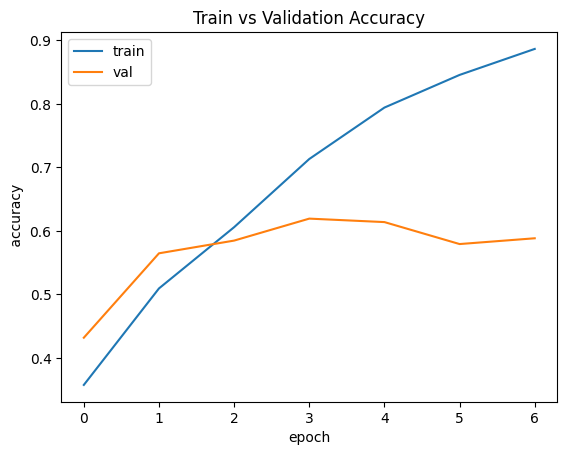

In [22]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'] , label='train')
plt.plot(history.history['val_accuracy'] , label='val')
plt.xlabel('epoch')
plt.ylabel(' accuracy')
plt.legend()
plt.title('Train vs Validation Accuracy')
plt.show()

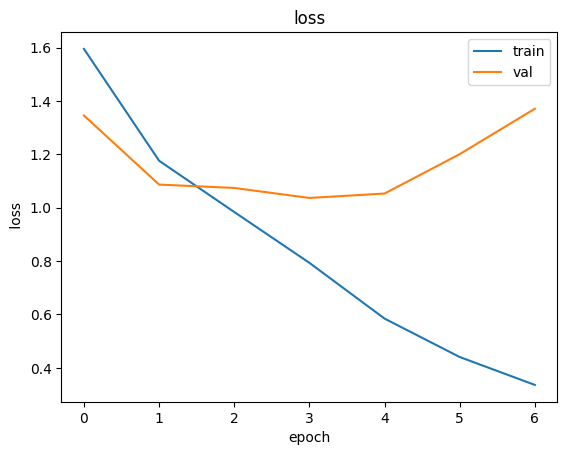

In [23]:
plt.plot(history.history['loss'] , label='train')
plt.plot(history.history['val_loss'] , label='val')
plt.xlabel('epoch')
plt.ylabel(' loss')
plt.legend()
plt.title('loss')
plt.show()

In [34]:
import cv2
img = cv2.imread('test.png')
img = cv2.resize(img, (128,128))
img = cv2.cvtColor(img ,cv2.COLOR_BGR2RGB)
img = img / 255.0
img = img.reshape(1,128,128,3)
p_pred = model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


In [35]:
print(p_pred)

[[1.0909201e-06 1.4550851e-06 2.2656639e-01 1.8777719e-05 7.7341223e-01]]


In [37]:
import numpy as np 
p = np.argmax(p_pred)
print(p)

4


In [39]:
class_names[p]

'tulip'